# K-Means Clustering of Bat Passes By Phonic Features
K-Means clustering is an unsupervised machine learning technique to cluster cases (e.g., bat passes) into groups by their numerical features. It's a method of partitional clustering, where every case must fit in one and only one group. 

Steps
1. import and visualize data using a scatterplot
2. drop some columns
3. use StandardScaler to get all variables on the same scale
4. use Elbow method to determine best number of clusters
5. use K-means clustering to fit cases into clusters and append to original data
6. explore characterstics of the clusters and plot using a scatterplot
7. export results

Author: K Rubio Last modified: 10/11/2025

In [2]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
from scipy.stats import zscore
import seaborn as sns
from sklearn.model_selection import train_test_split

In [93]:
# import the data
df = pd.read_csv("ma_bat_passes.csv")
df

,filename,duration_ms,ici_ms,min_freq,max_freq,peak_freq,slope
0,bat_20241020_1756.wav,44,185,25,31,26,-270
1,bat_20241020_1818_trimmed.wav,21,121,29,40,30,-792
2,bat_20241020_1826_bp4.wav,29,74,26,42,31,-1457
3,bat_20241020_1826_bp5.wav,45,214,25,32,26,-257
4,bat_20241020_1832_bp5.wav,30,93,28,41,31,-1241
...,...,...,...,...,...,...,...
98,bat_20250914_2055_bp5.wav,29,232,27,30,29,-160
99,bat_20250914_2055_bp6.wav,22,390,17,23,20,-619
100,bats_20241020_1837_bp2.wav,41,191,25,35,28,-312
101,bats_20241020_1841_bp4.wav,41,191,25,35,28,-312


<Axes: xlabel='duration_ms', ylabel='peak_freq'>

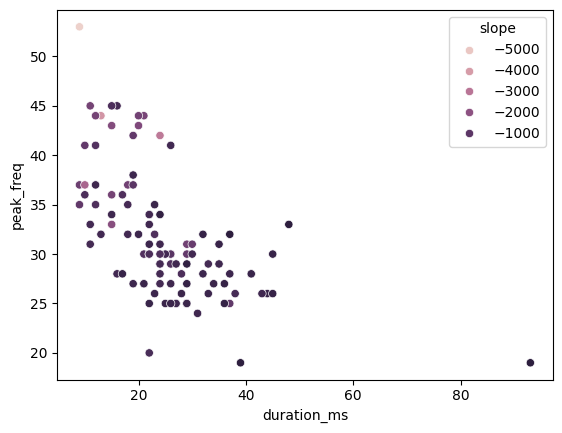

In [94]:
# Use 2 of the variables to look at a scatterplot
sns.scatterplot(data = df, x = 'duration_ms', y = 'peak_freq', hue = 'slope')

In [95]:
cols_to_drop = ['filename', 'ici_ms']
df.drop(cols_to_drop, axis=1, inplace=True)
df

,duration_ms,min_freq,max_freq,peak_freq,slope
0,44,25,31,26,-270
1,21,29,40,30,-792
2,29,26,42,31,-1457
3,45,25,32,26,-257
4,30,28,41,31,-1241
...,...,...,...,...,...
98,29,27,30,29,-160
99,22,17,23,20,-619
100,41,25,35,28,-312
101,41,25,35,28,-312


In [96]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

<Axes: >

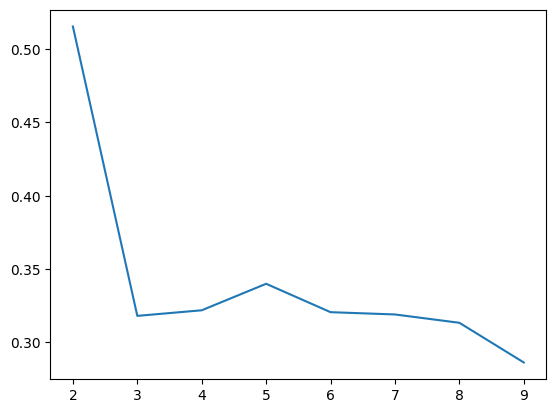

In [97]:
# Elbow method to determine best number of clusters
K = range(2, 10)
fits = []
score = []

for k in K:
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(X)
    fits.append(model)
    # Append the silhouette score to scores
    score.append(silhouette_score(X, model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)

Going to go with 3 clusters based on this graph, although 9 could be an alternative

In [98]:
k = 3 # number of groups
kmeans = KMeans(n_clusters=k, random_state=0) # initialize kmeans algorithm
labels = kmeans.fit_predict(X) # fit and predict to generate labels
df['cluster'] = labels # append those labels to the original df
df

,duration_ms,min_freq,max_freq,peak_freq,slope,cluster
0,44,25,31,26,-270,0
1,21,29,40,30,-792,2
2,29,26,42,31,-1457,2
3,45,25,32,26,-257,0
4,30,28,41,31,-1241,2
...,...,...,...,...,...,...
98,29,27,30,29,-160,0
99,22,17,23,20,-619,0
100,41,25,35,28,-312,0
101,41,25,35,28,-312,0


In [99]:
# check how many bat passes are in each cluster
df['cluster'].value_counts()

cluster
2    45
0    41
1    17
Name: count, dtype: int64

In [106]:
# Check the characteristics of each group
columns = ['duration_ms', 'min_freq', 'max_freq', 'peak_freq', 'slope']
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=columns
)
print(centers)

   duration_ms   min_freq   max_freq  peak_freq        slope
0    33.780488  24.609756  31.487805  26.463415  -370.682927
1    15.588235  39.294118  55.588235  43.411765 -2009.882353
2    20.200000  29.800000  37.333333  32.266667  -699.977778


Group 0 are lower frequency bats (~26 kHz with longer duration and flatter calls)
Group 1 are the highest frequency bats (~43 kHz with shortest duration and steepest slope)
Group 2 are medium frequency bats (~32 kHz with medium duration and medium slope)

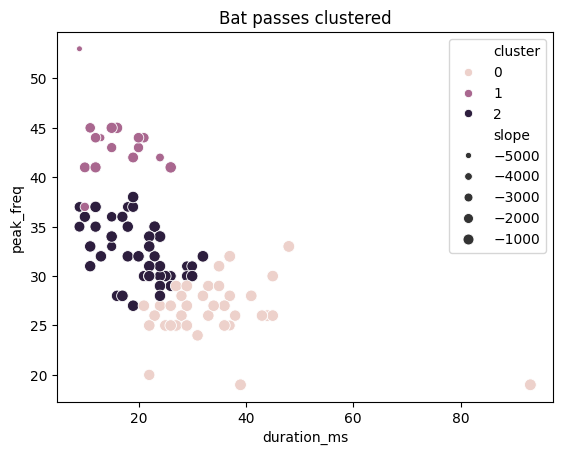

In [100]:
# Scatterplot using hue to highlight cluster
sns.scatterplot(
    data=df,
    x='duration_ms',
    y='peak_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Bat passes clustered")
plt.show()

In [66]:
# Export results to csv
df.to_csv("output/cluster_results.csv", columns=columns, index=False)